# Africapolis Density Scenario Shapefiles — 探索
运行每个 cell，结果就地显示。目标是搞清楚：
- 文件结构和命名规律
- 每个 shapefile 的字段（columns）
- geometry 类型和坐标系
- 与 nodes 数据的连接键
- 三种 density scenario 的具体差异

In [3]:
import os
import glob
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── 修改这里：你的 Density_Scenarios_Paper 路径 ──────────────────────────
BASE_DIR = "../input/Density_Scenarios_Paper"
# ────────────────────────────────────────────────────────────────────────

print(f"Looking in: {os.path.abspath(BASE_DIR)}")
print(f"Exists: {os.path.exists(BASE_DIR)}")

Looking in: /home/liang/Documents/Research/Africa_Transports/input/Density_Scenarios_Paper
Exists: True


## 1. 目录结构总览

In [4]:
# 列出所有子目录和文件
all_files = []
for root, dirs, files in os.walk(BASE_DIR):
    for f in files:
        all_files.append(os.path.join(root, f))

# 按扩展名统计
exts = pd.Series([os.path.splitext(f)[1].lower() for f in all_files])
print("=== 文件扩展名统计 ===")
print(exts.value_counts().to_string())
print(f"\n总文件数: {len(all_files)}")

=== 文件扩展名统计 ===
.xlsx    1134
.txt     1134
.tif     1128
.qmd       54
.prj       54
.shx       54
.shp       54
.dbf       54
.cpg       54

总文件数: 3720


In [5]:
# 列出所有 .shp 文件
shp_files = sorted(glob.glob(os.path.join(BASE_DIR, "**/*.shp"), recursive=True))
print(f"共找到 {len(shp_files)} 个 shapefile:\n")
for f in shp_files:
    rel = os.path.relpath(f, BASE_DIR)
    size_kb = os.path.getsize(f) / 1024
    print(f"  {rel:60s}  {size_kb:8.1f} KB")

共找到 54 个 shapefile:

  CA/CAF100002.shp                                                 511.2 KB
  CA/CMR100002.shp                                                3433.4 KB
  CA/COG100002.shp                                                 937.6 KB
  CA/GAB100002.shp                                                 632.9 KB
  CA/GEQ100002.shp                                                 225.0 KB
  CA/SDS100002.shp                                                1716.9 KB
  CA/SUD100002.shp                                                4329.4 KB
  CA/TCD100002.shp                                                3375.2 KB
  CA/ZAR100002.shp                                                7710.8 KB
  EA/BDI100002.shp                                               22613.2 KB
  EA/DJI100002.shp                                                  88.5 KB
  EA/ERI100002.shp                                                 160.7 KB
  EA/ETH1000022.shp                                              12

In [7]:
# 解析文件名规律：区域、国家、scenario
records = []
for f in shp_files:
    parts = os.path.normpath(f).split(os.sep)
    basename = os.path.splitext(os.path.basename(f))[0]
    # 找到 BASE_DIR 之后的层级
    rel_parts = parts[len(os.path.normpath(BASE_DIR).split(os.sep)):]
    records.append({
        "path": f,
        "subfolder": rel_parts[0] if len(rel_parts) > 1 else "",
        "basename": basename,
        "depth": len(rel_parts),
    })

df_files = pd.DataFrame(records)
print("=== 子文件夹 ===")
print(df_files["subfolder"].value_counts().to_string())
print("\n=== basename 样本 ===")
print(df_files["basename"].head(20).to_string())

=== 子文件夹 ===
subfolder
WA         14
SA         10
CA          9
EA          9
Insular     6
NA          5
NIG         1

=== basename 样本 ===
0      CAF100002
1      CMR100002
2      COG100002
3      GAB100002
4      GEQ100002
5      SDS100002
6      SUD100002
7      TCD100002
8      ZAR100002
9      BDI100002
10     DJI100002
11     ERI100002
12    ETH1000022
13    KEN1000022
14     RWA100002
15     SOM100002
16     TZA100002
17     UGA100002
18     COM100002
19     CPV100002


## 2. 读取一个样本 shapefile，检查字段

In [8]:
# 读第一个 shapefile 作为样本
sample_path = shp_files[0]
print(f"Sample: {os.path.relpath(sample_path, BASE_DIR)}\n")

gdf = gpd.read_file(sample_path)
print(f"Shape: {gdf.shape}")
print(f"CRS: {gdf.crs}")
print(f"Geometry types: {gdf.geometry.geom_type.value_counts().to_dict()}")
print(f"\nColumns:")
for col in gdf.columns:
    dtype = gdf[col].dtype
    n_unique = gdf[col].nunique() if col != 'geometry' else '-'
    sample_val = gdf[col].iloc[0] if col != 'geometry' else f"<{gdf.geometry.geom_type.iloc[0]}>"
    print(f"  {col:30s} dtype={str(dtype):12s} nunique={str(n_unique):6s} sample={sample_val}")

Sample: CA/CAF100002.shp

Shape: (47, 18)
CRS: EPSG:4326
Geometry types: {'Polygon': 44, 'MultiPolygon': 3}

Columns:
  Name                           dtype=object       nunique=46     sample=Bangui
  Iso                            dtype=object       nunique=1      sample=CAF
  Idint                          dtype=object       nunique=47     sample=CAF7100000
  Pta2020                        dtype=float64      nunique=47     sample=1389150.0
  Ptv2020                        dtype=float64      nunique=46     sample=705231.0
  Area2020                       dtype=float64      nunique=44     sample=138.87
  Nbu2020                        dtype=float64      nunique=2      sample=3.0
  Internat                       dtype=object       nunique=0      sample=None
  Valid                          dtype=object       nunique=1      sample=valid
  Xbary                          dtype=float64      nunique=45     sample=18.55
  Ybary                          dtype=float64      nunique=46     sample

ERROR 1: libspdlog.so.1.15: cannot open shared object file: No such file or directory
ERROR 1: libspdlog.so.1.15: cannot open shared object file: No such file or directory


In [9]:
# 显示前5行（非geometry列）
non_geom = [c for c in gdf.columns if c != 'geometry']
gdf[non_geom].head()

,Name,Iso,Idint,Pta2020,Ptv2020,Area2020,Nbu2020,Internat,Valid,Xbary,Ybary,Pta2015,Ptv2015,Area2015,Nbu2015,PTA2015_2,index
0,Bangui,CAF,CAF7100000,1389150.0,705231.0,138.87,3.0,None,valid,18.55,4.42,0.0,0.0,0.0,0.0,1009375.0,1
1,Berberati,CAF,CAF2111001,102005.0,102005.0,15.43,1.0,None,valid,15.79,4.26,0.0,0.0,0.0,0.0,95164.0,2
2,Bambari,CAF,CAF4311001,79876.0,79876.0,11.42,1.0,None,valid,20.67,5.77,0.0,0.0,0.0,0.0,52210.0,3
3,Carnot,CAF,CAF2131001,78000.0,78000.0,8.24,1.0,None,valid,15.88,4.94,0.0,0.0,0.0,0.0,60184.0,4
4,Bouar,CAF,CAF2213001,69428.0,69428.0,11.21,1.0,None,valid,15.60,5.93,0.0,0.0,0.0,0.0,48293.0,5


In [10]:
# 统计信息
print("=== 数值列统计 ===")
print(gdf[non_geom].describe().to_string())

=== 数值列统计 ===
            Pta2020        Ptv2020    Area2020    Nbu2020      Xbary      Ybary  Pta2015  Ptv2015  Area2015  Nbu2015     PTA2015_2      index
count  4.700000e+01      47.000000   47.000000  47.000000  47.000000  47.000000     47.0     47.0      47.0     47.0  4.700000e+01  47.000000
mean   5.798625e+04   42711.680851    7.058298   1.042553  18.533617   5.789362      0.0      0.0       0.0      0.0  3.967176e+04  24.000000
std    1.994177e+05  100928.279296   19.930122   0.291730   2.779335   1.387421      0.0      0.0       0.0      0.0  1.458392e+05  13.711309
min    1.040000e+04       0.000000    1.110000   1.000000  14.830000   3.520000      0.0      0.0       0.0      0.0  0.000000e+00   1.000000
25%    1.597950e+04   15150.000000    2.015000   1.000000  16.405000   4.770000      0.0      0.0       0.0      0.0  0.000000e+00  12.500000
50%    2.160000e+04   21154.000000    3.000000   1.000000  18.000000   5.700000      0.0      0.0       0.0      0.0  1.596600e+04  24

## 3. 检查所有 shapefile 的字段一致性

In [11]:
# 读所有 shapefiles 的 columns + CRS（不读geometry内容，只读schema）
import fiona

schema_records = []
for f in shp_files:
    try:
        with fiona.open(f) as src:
            schema_records.append({
                "file": os.path.relpath(f, BASE_DIR),
                "n_features": len(src),
                "crs": str(src.crs),
                "geom_type": src.schema["geometry"],
                "fields": list(src.schema["properties"].keys()),
                "field_types": list(src.schema["properties"].values()),
            })
    except Exception as e:
        schema_records.append({"file": f, "error": str(e)})

df_schema = pd.DataFrame(schema_records)
print(f"Total files read: {len(df_schema)}")
print(f"\nGeometry types:")
print(df_schema['geom_type'].value_counts().to_string())
print(f"\nCRS:")
print(df_schema['crs'].value_counts().to_string())
print(f"\nn_features range: {df_schema['n_features'].min()} – {df_schema['n_features'].max()}")

Total files read: 54

Geometry types:
geom_type
Polygon    54

CRS:
crs
EPSG:4326    54

n_features range: 1 – 1469


In [12]:
# 检查字段是否在所有文件中一致
field_sets = [frozenset(r['fields']) for r in schema_records if 'fields' in r]
unique_field_sets = set(field_sets)
print(f"Unique field schemas: {len(unique_field_sets)}")

if len(unique_field_sets) == 1:
    print("✅ 所有文件字段完全一致")
    print("Fields:", sorted(list(unique_field_sets)[0]))
else:
    print("⚠️  字段不一致，各组如下：")
    for i, fs in enumerate(unique_field_sets):
        files_with_this = [r['file'] for r in schema_records 
                           if 'fields' in r and frozenset(r['fields']) == fs]
        print(f"\nGroup {i+1} ({len(files_with_this)} files): {sorted(fs)}")
        print("  Files:", files_with_this[:5], "..." if len(files_with_this) > 5 else "")

Unique field schemas: 30
⚠️  字段不一致，各组如下：

Group 1 (1 files): ['Area2015', 'Area2020', 'IDINT', 'Internat', 'NAME2015', 'N_2020', 'NbU2015', 'NbU2020', 'Note', 'PTA2015', 'PTA2020', 'PTv2015', 'PTv2020', 'Provincia', 'Valid', 'Xbary', 'Ybary', 'index']
  Files: ['SA/MOZ100002.shp'] 

Group 2 (1 files): ['Area2015', 'Area2020', 'IDINT', 'ISO', 'Internat', 'N_sd', 'NbU2015', 'NbU2020', 'PTA2015', 'PTA2020', 'PTv2015', 'PTv2020', 'Valid', 'index', 'open', 'xbary', 'ybary']
  Files: ['CA/GAB100002.shp'] 

Group 3 (1 files): ['Altz', 'Area2020', 'Idint', 'Internat', 'Iso', 'N_sd', 'Nbu2020', 'Pta2020', 'Ptv2020', 'Valid', 'Xlon', 'Ylat', 'index']
  Files: ['SA/AGO1000022.shp'] 

Group 4 (1 files): ['Altz', 'Area2015', 'Area2020', 'Idint', 'Internat', 'Iso', 'N_sd', 'Nbu2015', 'Nbu2020', 'Pta2015', 'Pta2020', 'Ptv2015', 'Ptv2020', 'Valid', 'Xlon', 'Ylat', 'index', 'rown']
  Files: ['NA/EGY100002.shp'] 

Group 5 (1 files): ['Area2015', 'Area2020', 'Dens2015', 'Idint', 'Internat', 'Iso', 'Name'

In [13]:
# 完整 schema 表格
df_schema[['file','n_features','geom_type','crs','fields']]

,file,n_features,geom_type,crs,fields
0,CA/CAF100002.shp,47,Polygon,EPSG:4326,"[Name, Iso, Idint, Pta2020, Ptv2020, Area2020,..."
1,CA/CMR100002.shp,146,Polygon,EPSG:4326,"[N_sd, ISO, IDINT, PTA2020, PTv2020, Area2020,..."
2,CA/COG100002.shp,29,Polygon,EPSG:4326,"[N_sd, ISO, ID_INT, PTA2020, PTv2020, Area2020..."
3,CA/GAB100002.shp,15,Polygon,EPSG:4326,"[N_sd, ISO, IDINT, PTA2020, PTv2020, Area2020,..."
4,CA/GEQ100002.shp,5,Polygon,EPSG:4326,"[N_sd, ISO, IDINT, PTA2020, PTv2020, Area2020,..."
5,CA/SDS100002.shp,71,Polygon,EPSG:4326,"[N_sd, ISO, IDINT, PTA2020, PTv2020, Area2020,..."
6,CA/SUD100002.shp,324,Polygon,EPSG:4326,"[N_sd, ISO, IDINT, PTA2020, Area2020, Internat..."
7,CA/TCD100002.shp,125,Polygon,EPSG:4326,"[N_sd, Idint, Iso, Pta2020, Ptv2020, Area2020,..."
8,CA/ZAR100002.shp,612,Polygon,EPSG:4326,"[N_sd, Idint, Iso, Pta2020, Ptv2020, Area2020,..."
9,EA/BDI100002.shp,174,Polygon,EPSG:4326,"[N_sd, Idint, Iso, Pta2020, Ptv2020, Area2020,..."


## 4. 三种 Density Scenario 的区别

In [14]:
# 尝试识别 scenario 类型：从文件名或字段中寻找 high/consolidated/low 的痕迹
for f in shp_files:
    basename = os.path.basename(f).lower()
    if any(k in basename for k in ['high','consol','low','hd','cd','ld']):
        print(f"Scenario keyword in filename: {os.path.relpath(f, BASE_DIR)}")

# 检查字段名中是否有 scenario 相关信息
if schema_records and 'fields' in schema_records[0]:
    print("\nAll fields in first file:", schema_records[0]['fields'])

Scenario keyword in filename: CA/TCD100002.shp

All fields in first file: ['Name', 'Iso', 'Idint', 'Pta2020', 'Ptv2020', 'Area2020', 'Nbu2020', 'Internat', 'Valid', 'Xbary', 'Ybary', 'Pta2015', 'Ptv2015', 'Area2015', 'Nbu2015', 'PTA2015_2', 'index']


In [15]:
# 如果同一个国家有多个 shapefile，对比它们
# 提取国家代码（假设basename格式如 CAF100002）
import re

for rec in schema_records:
    basename = os.path.splitext(os.path.basename(rec['file']))[0]
    # 尝试匹配 3字母国家代码 + 数字
    m = re.match(r'^([A-Z]{2,3})(\d+)', basename)
    rec['country_code'] = m.group(1) if m else basename[:3]
    rec['file_num'] = m.group(2) if m else ''

df_schema2 = pd.DataFrame(schema_records)
print("Country codes found:")
print(df_schema2['country_code'].value_counts().to_string())

print("\nFiles per country (>1 might indicate multiple scenarios per country):")
multi = df_schema2.groupby('country_code').size()
print(multi[multi > 1].to_string())

Country codes found:
country_code
CAF    1
CMR    1
COG    1
GAB    1
GEQ    1
SDS    1
SUD    1
TCD    1
ZAR    1
BDI    1
DJI    1
ERI    1
ETH    1
KEN    1
RWA    1
SOM    1
TZA    1
UGA    1
COM    1
CPV    1
MDG    1
MUS    1
STP    1
SYC    1
DZA    1
EGY    1
LBY    1
MAR    1
TUN    1
NGA    1
AGO    1
BWA    1
LSO    1
MOZ    1
MWI    1
NAM    1
SWZ    1
ZAF    1
ZMB    1
ZWE    1
BEN    1
BFA    1
CIV    1
GHA    1
GIN    1
GMB    1
GNB    1
LIB    1
MLI    1
MRT    1
NER    1
SEN    1
SLE    1
TGO    1

Files per country (>1 might indicate multiple scenarios per country):
Series([], )


## 5. 可视化：一个国家的所有 polygons

In [16]:
# 选一个国家，把它的所有 shapefile 叠加画出来
FOCUS_COUNTRY = "NIG"   # ← 可以改成你想看的区域/国家文件夹

focus_files = [f for f in shp_files if FOCUS_COUNTRY in f]
print(f"Files for '{FOCUS_COUNTRY}': {len(focus_files)}")
for f in focus_files:
    print(" ", os.path.relpath(f, BASE_DIR))

Files for 'NIG': 1
  NIG/NGA100002.shp


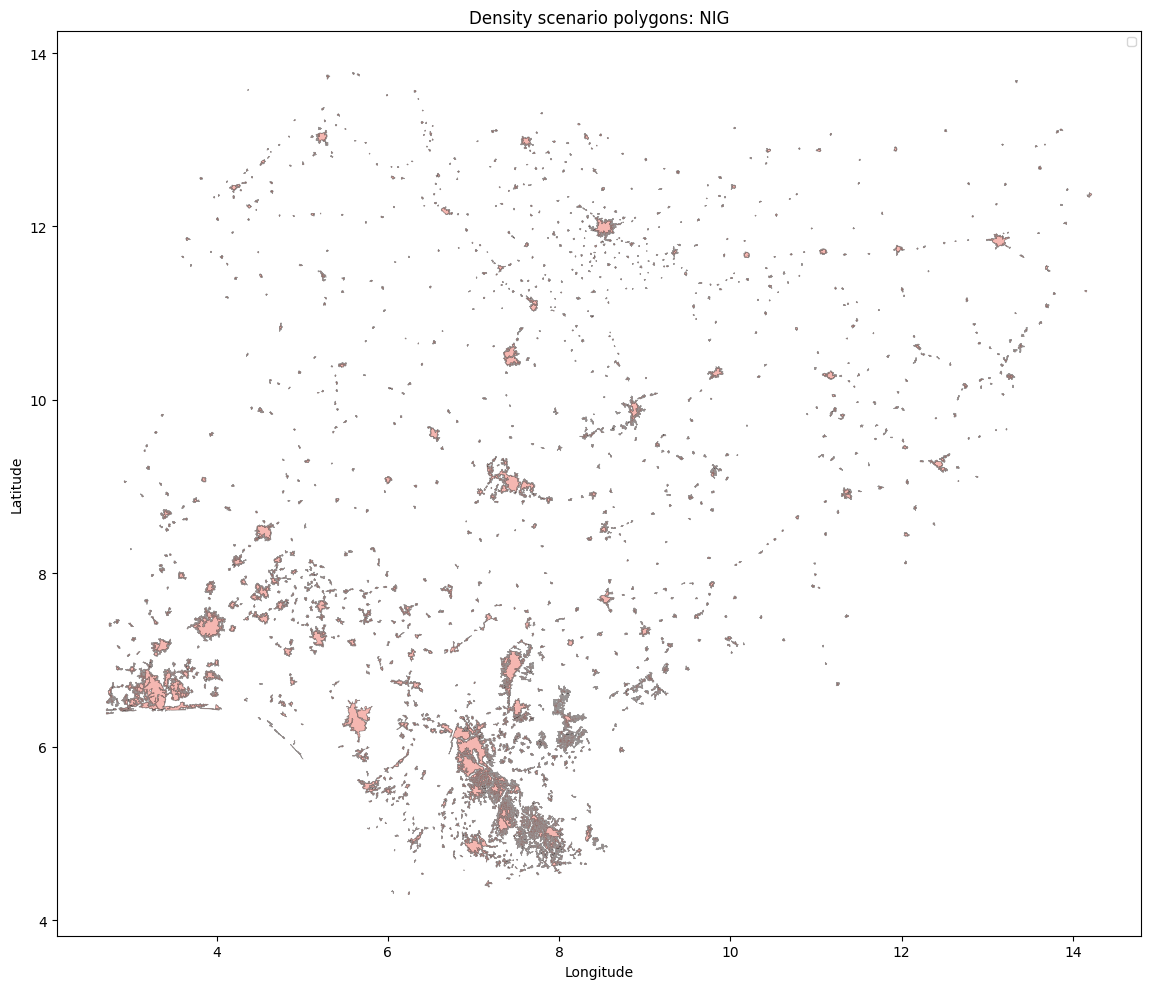

NGA100002.shp: bbox=[ 2.711  4.295 14.221 13.776], n=1469


In [17]:
# 读取并叠加显示（如果有多个文件则分色）
if focus_files:
    gdfs = []
    for f in focus_files:
        g = gpd.read_file(f)
        g['source_file'] = os.path.basename(f)
        gdfs.append(g)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    
    for i, (g, f) in enumerate(zip(gdfs, focus_files)):
        g.plot(ax=ax, alpha=0.4, color=colors[i % len(colors)],
               edgecolor='black', linewidth=0.5,
               label=os.path.basename(f))
    
    ax.set_title(f"Density scenario polygons: {FOCUS_COUNTRY}")
    ax.legend(fontsize=8)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()
    
    # Print bounding boxes
    for g, f in zip(gdfs, focus_files):
        bounds = g.total_bounds  # [minx, miny, maxx, maxy]
        print(f"{os.path.basename(f)}: bbox={bounds.round(3)}, n={len(g)}")

## 6. 连接键：polygon 如何对应到 nodes？

In [19]:
# 读 nodes 数据
nodes = pd.read_csv("../input/AfricaNetworkNodes.csv")
afp   = pd.read_csv("../input/Africapolis_2050.csv")

print("Nodes columns:", list(nodes.columns))
print("Africapolis columns:", list(afp.columns[:15]), "...")

# 读一个 shapefile，看它的字段
gdf_s = gpd.read_file(shp_files[0])
print(f"\nSample shapefile ({os.path.basename(shp_files[0])}) columns:")
print([c for c in gdf_s.columns if c != 'geometry'])

Nodes columns: ['name', 'agglosName', 'x', 'y', 'Pop2015', 'ISO3', 'Region', 'Between', 'degree']
Africapolis columns: ['Agglomeration_ID', 'Agglomeration_Name', 'ISO3', 'Longitude', 'Latitude', 'Population_1950', 'Population_1960', 'Population_1970', 'Population_1980', 'Population_1990', 'Population_2000', 'Population_2010', 'Population_2015', 'Population_2020', 'Population_2025'] ...

Sample shapefile (CAF100002.shp) columns:
['Name', 'Iso', 'Idint', 'Pta2020', 'Ptv2020', 'Area2020', 'Nbu2020', 'Internat', 'Valid', 'Xbary', 'Ybary', 'Pta2015', 'Ptv2015', 'Area2015', 'Nbu2015', 'PTA2015_2', 'index']


In [20]:
# 检查 shapefile 字段值，寻找与 Agglomeration_ID 或 agglosName 的交集
non_geom_cols = [c for c in gdf_s.columns if c != 'geometry']

for col in non_geom_cols:
    vals = set(gdf_s[col].dropna().astype(str))
    
    # Check overlap with node names
    node_names = set(nodes['agglosName'].dropna().astype(str))
    node_ids   = set(nodes['name'].dropna().astype(str))
    afp_ids    = set(afp['Agglomeration_ID'].dropna().astype(str))
    afp_names  = set(afp['Agglomeration_Name'].dropna().astype(str))
    
    overlap_name = len(vals & node_names)
    overlap_id   = len(vals & node_ids)
    overlap_afp_id   = len(vals & afp_ids)
    overlap_afp_name = len(vals & afp_names)
    
    if any(x > 0 for x in [overlap_name, overlap_id, overlap_afp_id, overlap_afp_name]):
        print(f"  Column '{col}':")
        print(f"    ↔ nodes.agglosName overlap: {overlap_name}")
        print(f"    ↔ nodes.name overlap:       {overlap_id}")
        print(f"    ↔ Africapolis ID overlap:   {overlap_afp_id}")
        print(f"    ↔ Africapolis Name overlap: {overlap_afp_name}")
        print(f"    Sample values: {list(vals)[:5]}")

  Column 'Name':
    ↔ nodes.agglosName overlap: 1
    ↔ nodes.name overlap:       0
    ↔ Africapolis ID overlap:   0
    ↔ Africapolis Name overlap: 36
    Sample values: ['Yaloke', 'Mbaere', 'Dekoa', 'Kaga-Bandoro', 'Bozoum']
  Column 'index':
    ↔ nodes.agglosName overlap: 12
    ↔ nodes.name overlap:       12
    ↔ Africapolis ID overlap:   37
    ↔ Africapolis Name overlap: 0
    Sample values: ['28', '27', '13', '11', '10']


In [21]:
# 全量检查：所有 shapefile 的字段样本
print("=== 每个 shapefile 的字段和前3行 ===")
for f in shp_files:
    try:
        g = gpd.read_file(f, rows=3)
        nc = [c for c in g.columns if c != 'geometry']
        print(f"\n{os.path.relpath(f, BASE_DIR)}")
        print(g[nc].to_string(index=False))
    except Exception as e:
        print(f"  ERROR: {e}")

=== 每个 shapefile 的字段和前3行 ===

CA/CAF100002.shp
     Name Iso      Idint   Pta2020  Ptv2020  Area2020  Nbu2020 Internat Valid  Xbary  Ybary  Pta2015  Ptv2015  Area2015  Nbu2015  PTA2015_2  index
   Bangui CAF CAF7100000 1389150.0 705231.0    138.87      3.0     None valid  18.55   4.42      0.0      0.0       0.0      0.0  1009375.0      1
Berberati CAF CAF2111001  102005.0 102005.0     15.43      1.0     None valid  15.79   4.26      0.0      0.0       0.0      0.0    95164.0      2
  Bambari CAF CAF4311001   79876.0  79876.0     11.42      1.0     None valid  20.67   5.77      0.0      0.0       0.0      0.0    52210.0      3

CA/CMR100002.shp
     N_sd ISO    IDINT   PTA2020   PTv2020  Area2020  NbU2020 Internat      Valid  Xbary  Ybary Note  GrowthArea  PTa2015_su  index
  Yaounde CMR CMR02070 4720000.0 3255651.0    406.30      0.0     None Valid 2020 11.531  3.919 None    1.279081   3901680.0      1
   Douala CMR CMR05040 3355000.0 3322170.0    263.60      0.0     None Valid 2020  

## 7. 面积分析：三种 scenario 的 polygon 大小对比

In [22]:
# 读所有 shapefile，计算面积（先统一投影到等积坐标系）
all_gdfs = []
for f in shp_files:
    try:
        g = gpd.read_file(f)
        g['source_file'] = os.path.basename(f)
        g['region'] = os.path.basename(os.path.dirname(f))  # 子文件夹名
        all_gdfs.append(g)
    except Exception as e:
        print(f"Error reading {f}: {e}")

if all_gdfs:
    gdf_all = pd.concat(all_gdfs, ignore_index=True)
    print(f"Total polygons loaded: {len(gdf_all)}")
    print(f"Columns: {[c for c in gdf_all.columns if c != 'geometry']}")
    
    # Project to Africa Albers Equal Area for area calculation
    gdf_proj = gdf_all.to_crs("+proj=aea +lat_1=20 +lat_2=-23 +lat_0=0 +lon_0=25")
    gdf_all['area_km2'] = gdf_proj.geometry.area / 1e6
    
    print("\nArea stats by region folder:")
    print(gdf_all.groupby('region')['area_km2'].describe().round(1).to_string())

Total polygons loaded: 9000
Columns: ['Name', 'Iso', 'Idint', 'Pta2020', 'Ptv2020', 'Area2020', 'Nbu2020', 'Internat', 'Valid', 'Xbary', 'Ybary', 'Pta2015', 'Ptv2015', 'Area2015', 'Nbu2015', 'PTA2015_2', 'index', 'source_file', 'region', 'N_sd', 'ISO', 'IDINT', 'PTA2020', 'PTv2020', 'NbU2020', 'Note', 'GrowthArea', 'PTa2015_su', 'ID_INT', 'xbary', 'ybary', 'PTA2015', 'PTv2015', 'NbU2015', 'open', 'PTa2015', 'NAME', 'Xlon', 'Ylat', 'AreaGrowth', 'Altz', 'PTa2020', 'zAlt', 'Transfront', 'Zalt', 'N_1', 'rown', 'StatutLoc', 'CodeAggloP', 'Test', 'Area2020mo', 'D2020', 'Zone', 'state_code', 'N_2020', 'NAME2015', 'Provincia', 'Forme', 'Field5', 'CentroidX', 'CentroidY', 'AltZ', 'PTV2015', 'Dens2015', 'PT2015A', 'PT2015v', 'ISO_2', 'IDINT_2', 'PT2015a_2', 'PT2015v_2', 'Skm2', 'NbU', 'VarArea', 'EstProvAre', 'EstProvDem']

Area stats by region folder:
          count  mean    std  min  25%  50%   75%      max
region                                                    
CA       1374.0  12.3   55

In [23]:
# 如果 shapefile 字段里有 scenario 标识，分组对比面积
# （根据上面发现的字段名替换 'SCENARIO_COL'）
SCENARIO_COL = None   # ← 填入你在上面发现的场景字段名，如 'scenario' 或 'density'

if SCENARIO_COL and SCENARIO_COL in gdf_all.columns:
    print(f"Area by scenario ('{SCENARIO_COL}'):")
    print(gdf_all.groupby(SCENARIO_COL)['area_km2']
          .agg(['count','mean','median','sum']).round(1).to_string())
    
    fig, ax = plt.subplots(figsize=(8,4))
    for sc in gdf_all[SCENARIO_COL].unique():
        subset = gdf_all[gdf_all[SCENARIO_COL] == sc]['area_km2']
        subset[subset < subset.quantile(0.99)].hist(ax=ax, bins=50, alpha=0.5, label=str(sc))
    ax.set_xlabel('Area (km²)')
    ax.set_title('Urban polygon area distribution by density scenario')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("SCENARIO_COL not set — fill it in based on what you found above.")

SCENARIO_COL not set — fill it in based on what you found above.


## 8. 小结：请记录以下信息，告诉 Claude

运行完上面所有 cell 后，请截图或复制以下信息：

1. **Section 1**：shapefile 总数 + 子文件夹列表
2. **Section 2**：样本 shapefile 的全部字段名
3. **Section 3**：字段是否一致？有哪几种字段组合？
4. **Section 4**：三种 scenario 是分文件还是同一文件的不同列/字段？
5. **Section 6**：哪个字段可以用来连接 nodes/Africapolis？
6. **Section 7（如果 Section 4 找到了 SCENARIO_COL）**：三种 scenario 的面积差异大致是多少？